In [36]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_absolute_percentage_error
)

In [2]:
# Load Data
X_train = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\X_train.csv",
    index_col="Date",
    parse_dates=True
)
X_test = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\X_test.csv",
    index_col="Date",
    parse_dates=True
)
y_train = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\y_train.csv",
    index_col="Date",
    parse_dates=True
)
y_test = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\y_test.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
# Converting DataFrame into Series
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
# Load Scaler
scaler = joblib.load(r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\models\scaler.joblib")

In [5]:
# Scaling
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
lr_pred = lr_model.predict(X_test_scaled)

print("Coefficient:", lr_model.coef_[0])
print("Intercept:", lr_model.intercept_)
print("Predictions:", y_pred)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Coefficient: 0.015850262533655443
Intercept: -0.0005563653628401971
Predictions: [-1.13174816e-03 -3.97719102e-03  7.65740739e-03  2.07856552e-02
 -8.94172582e-03 -1.22546495e-02  2.38299982e-02 -1.49235827e-02
 -3.58778548e-02 -2.64592360e-03 -1.67368548e-02  4.67988431e-03
  1.20367949e-03  5.91071425e-03 -1.12411345e-02 -2.86653582e-02
 -2.00968444e-02 -3.56283134e-02 -2.14118325e-02 -8.83406411e-04
 -3.64849749e-02 -3.37228703e-02  7.09529082e-03 -1.34609477e-03
  3.38433505e-03 -1.65867058e-02 -1.50553077e-02 -1.49551070e-04
 -8.94492414e-03 -5.97822984e-03  1.21131900e-02 -2.04800231e-02
 -6.13156252e-03 -9.27228554e-03  3.42055504e-04  4.83095744e-03
 -7.49029669e-03 -5.63879737e-03  9.32563959e-03  2.59970735e-03
  1.32461534e-02  2.43387942e-02  2.22627129e-02  3.26814041e-02
  4.36622673e-02  2.90157385e-02  2.28526709e-02  3.21409775e-02
  1.51076594e-02  1.16746296e-02  2.87271082e-03 -6.02523879e-03
 -4.35248481e-03 -1.27514660e-02 -7.32943784e-03  2.16742702e-02
  6.31856

In [8]:
from sklearn.svm import SVR

svr_model = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.01)
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [9]:
svr_pred = svr_model.predict(X_test_scaled)

In [10]:
print("MAE:", mean_absolute_error(y_test, svr_pred))
print("MSE:", mean_squared_error(y_test, svr_pred))
print("R²:", r2_score(y_test, svr_pred))

MAE: 0.06396605295034052
MSE: 0.007538496412603363
R²: -3.11139209737338


In [11]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train_scaled, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test, reference=train_data)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

# Train model
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=1000
)

In [12]:
y_pred = model.predict(X_test_scaled)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.034484008551275924
MSE: 0.002470464247889556
R²: -0.34735716908153735


In [15]:
single_input = pd.DataFrame([{
    "Close": 119.84,
    "MA5": 115.25,
    "MA14": 116.22,
    "Daily Return": 1.13,
    "RSI": 66.19,
    "Bollinger Band Width": 0.473,
    "High-Low Range": 4.69,
    "Relative Volume": 0.54
}])

single_scale = scaler.transform(single_input)

In [16]:
prediction = lr_model.predict(single_scale)

print("Predicted Target:", prediction[0])

Predicted Target: -0.03599626585971973


In [18]:
prediction = svr_model.predict(single_scale)

print("Predicted Target:", prediction[0])

Predicted Target: 0.028351878291061054


In [41]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.001,
    max_depth=10,
    random_state=42
)

In [42]:
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(y_test, y_pred)

# Adjusted R2
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("\n===== Regression Metrics =====")

print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R2    : {r2:.4f}")
print(f"Adj R2: {adjusted_r2:.4f}")
print(f"MAPE  : {mape:.4f}")


===== Regression Metrics =====
MAE   : 0.0345
MSE   : 0.0025
RMSE  : 0.0497
R2    : -0.3474
Adj R2: -0.3919
MAPE  : 229836635344.8673


In [45]:
X_train_scaled

array([[ 1.7700928 ,  1.7763072 ,  2.09892682, ...,  0.24163099,
        -0.51669823, -0.634863  ],
       [ 1.70214911,  1.74525287,  2.04774598, ...,  0.37811502,
         0.54640591, -0.07679599],
       [ 1.67768929,  1.71801232,  1.99604549, ...,  0.4578583 ,
        -0.09546437, -0.69308823],
       ...,
       [-1.36910874, -1.54023317, -1.5643143 , ...,  1.04056716,
        -0.70392323,  0.0817483 ],
       [-1.51254051, -1.51786994, -1.56288606, ...,  0.79094153,
        -0.32900367,  0.60343096],
       [-1.46672194, -1.48452472, -1.55617331, ...,  0.62976089,
         0.09002505, -0.45792836]], shape=(1004, 8))

In [ ]:
# Using Neural Network for Linear Regression
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

nn_model_lr = tf.keras.Sequential([
    tf.keras.Input(shape=(8,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn_model_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = nn_model_lr.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [67]:
nn_pred = nn_model_lr.predict(X_test_scaled).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


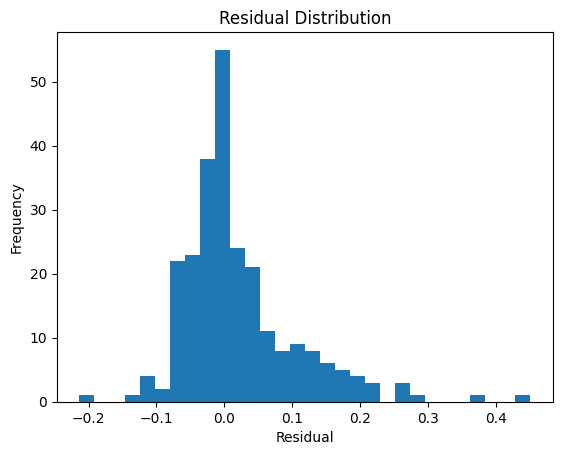

In [68]:
import matplotlib.pyplot as plt

residuals = y_test - nn_pred

plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()